In [ ]:
# Legal Notice Multi-Class Classification

## Programming For AI - Lab Assessment

### Student Name:M.Zohaib Latif
### SAP ID:68125

Dataset Classes:
- A: Contract Dispute
- B: Intellectual Property Claim
- C: Regulatory Compliance

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/zohiab5911/legal-notices-csv/legal_notices.csv')

print(df.head())

   id category                        label  \
0   1        C        Regulatory Compliance   
1   2        A             Contract Dispute   
2   3        B  Intellectual Property Claim   
3   4        A             Contract Dispute   
4   5        C        Regulatory Compliance   

                                              notice  
0  FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...  
1  NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...  
2  NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...  
3  BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...  
4  TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...  


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (600, 4)

Columns:
Index(['id', 'category', 'label', 'notice'], dtype='object')

Missing Values:
id          0
category    0
label       0
notice      0
dtype: int64


In [5]:
print(df.head(10))

   id category                        label  \
0   1        C        Regulatory Compliance   
1   2        A             Contract Dispute   
2   3        B  Intellectual Property Claim   
3   4        A             Contract Dispute   
4   5        C        Regulatory Compliance   
5   6        B  Intellectual Property Claim   
6   7        C        Regulatory Compliance   
7   8        C        Regulatory Compliance   
8   9        B  Intellectual Property Claim   
9  10        C        Regulatory Compliance   

                                              notice  
0  FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...  
1  NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...  
2  NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...  
3  BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...  
4  TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...  
5  NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...  
6  CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...  
7  ANTI-MONEY LAUNDERING COMPLIANCE DIRECT

In [6]:
print("Total Samples:", len(df))

print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nCategories:")
print(df['category'].value_counts())

print("\nAverage Notice Length:")
print(df['notice'].astype(str).apply(len).mean())

Total Samples: 600

Class Distribution:
label
Regulatory Compliance          200
Contract Dispute               200
Intellectual Property Claim    200
Name: count, dtype: int64

Categories:
category
C    200
A    200
B    200
Name: count, dtype: int64

Average Notice Length:
792.08


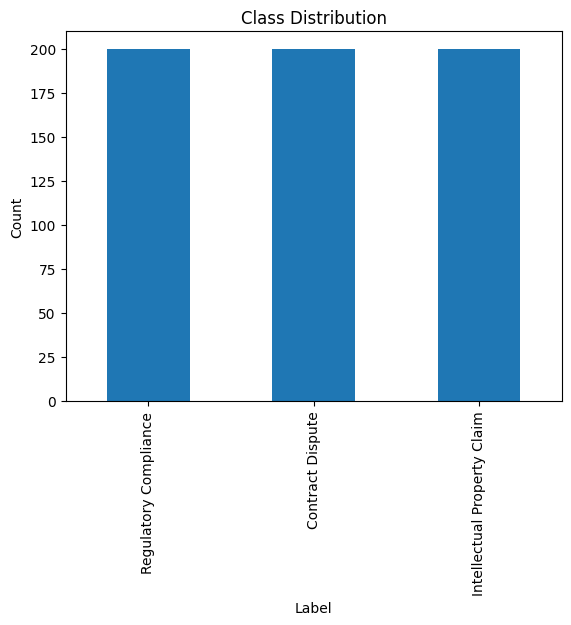

In [7]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

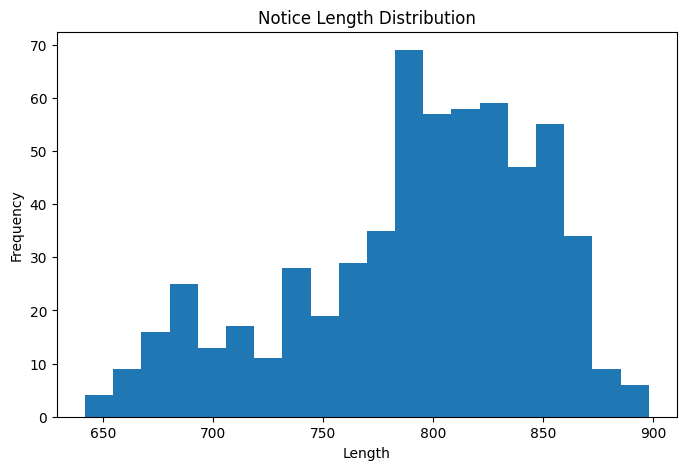

In [8]:
df['length'] = df['notice'].astype(str).apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['length'], bins=20)

plt.title("Notice Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
import re

stop_words = {
    'a','an','the','and','or','but','if','while','is','am','are',
    'was','were','be','been','being','have','has','had','do','does',
    'did','of','at','by','for','with','about','against','between',
    'into','through','during','before','after','above','below',
    'to','from','up','down','in','out','on','off','over','under',
    'again','further','then','once','here','there','when','where',
    'why','how','all','any','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same',
    'so','than','too','very','can','will','just'
}

In [15]:
def preprocess(text):

    text = str(text).lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [16]:
df['clean_notice'] = df['notice'].apply(preprocess)

df[['notice','clean_notice']].head()

,notice,clean_notice
0,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...,financial reporting non compliance notice glob...
1,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...,notice contract termination cause coastal logi...
2,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...,notice patent licensing obligation synthlab so...
3,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...,breach confidentiality notice horizon enterpri...
4,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...,telecommunications licence compliance notice p...


In [17]:
print("Class Distribution:")
print(df['label'].value_counts())

Class Distribution:
label
Regulatory Compliance          200
Contract Dispute               200
Intellectual Property Claim    200
Name: count, dtype: int64


## EDA Observation

The dataset contains 600 samples equally distributed across three classes (200 samples per class). Therefore, class imbalance is not a concern.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['clean_notice'])

print("BoW Shape:", X_bow.shape)

BoW Shape: (600, 887)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df['clean_notice'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (600, 887)


## Feature Extraction Observation

Both Bag of Words and TF-IDF generated 887 features from the legal notices dataset. These features will be used for training and comparing different machine learning models.

## Feature Extraction

Two feature extraction techniques were used:

1. Bag of Words (BoW) using CountVectorizer with max_features=5000.
2. TF-IDF using TfidfVectorizer with max_features=5000 and sublinear_tf=True.

TF-IDF helps reduce the impact of very common words and highlights more informative terms.

In [20]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training Samples:", len(y_train))
print("Testing Samples:", len(y_test))

Training Samples: 480
Testing Samples: 120


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy:
1.0


In [22]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

pred_nb = nb.predict(X_test_bow)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, pred_nb))

Naive Bayes Accuracy:
1.0


In [23]:
from sklearn.metrics import classification_report

print("===== Logistic Regression =====")
print(classification_report(y_test, pred_lr))

print("\n===== Naive Bayes =====")
print(classification_report(y_test, pred_nb))

===== Logistic Regression =====
                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00      1.00      1.00       120


===== Naive Bayes =====
                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00   

## Model Evaluation Observation

Both Logistic Regression and Naive Bayes achieved perfect performance on the test set with 100% accuracy, precision, recall, and F1-score.

This suggests that the three classes contain highly distinguishable textual patterns and keywords. The dataset appears to be well-structured and balanced, making classification easier for machine learning models.

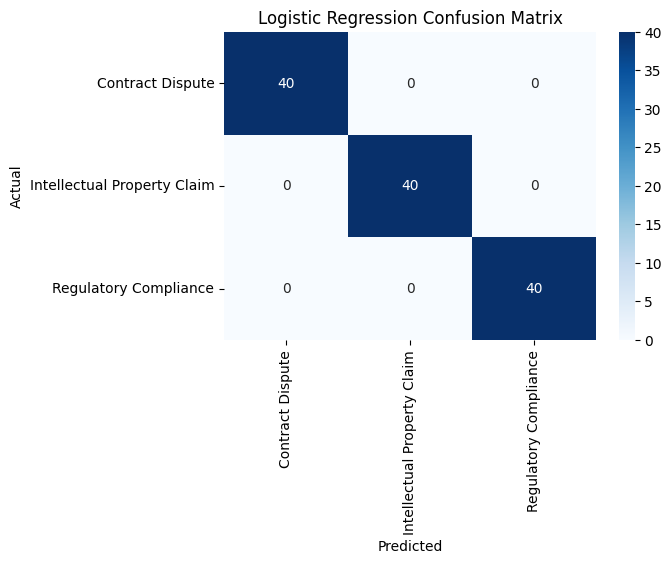

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

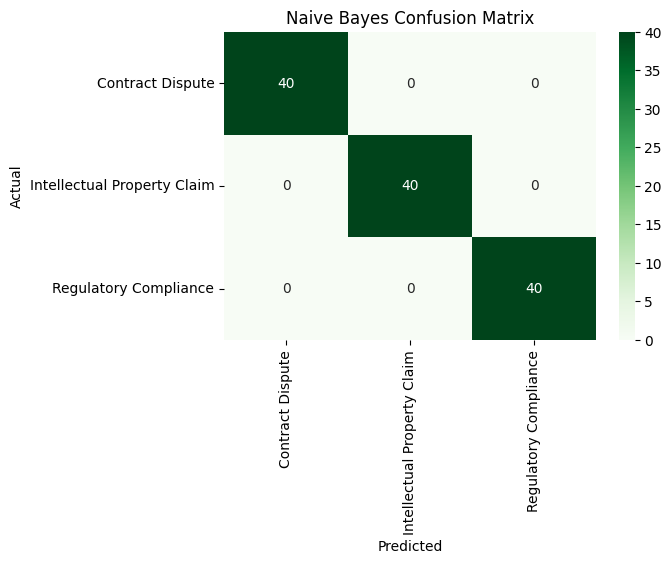

In [25]:
cm_nb = confusion_matrix(y_test, pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=nb.classes_,
    yticklabels=nb.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Problem Framing

The task is a multi-class text classification problem because the goal is to classify legal notices into one of three predefined categories.

### Assumptions

1. All legal notices are correctly labelled.
2. The training data represents real-world legal notices.
3. Future notices will follow similar writing patterns.

### Constraints

1. Fast prediction speed is required.
2. Model interpretability is important in legal applications.

### Evaluation Metric

Weighted F1-score is selected as the primary evaluation metric because it balances precision and recall while considering class distribution.

# Approach Comparison

## Approach 1: Logistic Regression with TF-IDF

Strengths:
- Works well for text classification.
- Handles high-dimensional sparse data effectively.
- Easy to interpret.

Weaknesses:
- Assumes linear decision boundaries.

## Approach 2: Naive Bayes with Bag of Words

Strengths:
- Fast training and prediction.
- Effective on text data.

Weaknesses:
- Assumes feature independence.

## Final Selection

Logistic Regression with TF-IDF is selected because it generally provides robust performance and captures the importance of informative words through TF-IDF weighting.

In [26]:
import pandas as pd

bow_features = bow.get_feature_names_out()

word_counts = X_bow.sum(axis=0).A1

top_words = pd.DataFrame({
    'Word': bow_features,
    'Frequency': word_counts
})

top_words = top_words.sort_values(
    by='Frequency',
    ascending=False
)

print(top_words.head(20))

           Word  Frequency
536      notice        923
873      within        691
209        date        660
212        days        634
820        this        623
473         ltd        490
817        that        480
151  compliance        427
191        corp        387
363       group        348
466         llc        340
224     demands        320
20    agreement        320
533         non        300
430          ip        295
86       breach        280
579    partners        271
189   copyright        264
859   violation        260
710      result        260


## Top Terms Analysis

The most frequent terms include "notice", "within", "date", "days", "compliance", "agreement", "breach", "copyright", and "violation".

These terms are highly relevant to legal notices and align with the dataset categories. For example:

- "agreement" and "breach" are commonly associated with Contract Dispute cases.
- "copyright" and "ip" are related to Intellectual Property Claims.
- "compliance" is strongly connected to Regulatory Compliance notices.

This indicates that the extracted features capture meaningful legal terminology and are useful for classification.

# Limitations and Bias

## Limitations

1. The dataset contains only 600 samples, which may not fully represent real-world legal notices.

2. The model relies only on textual features and does not consider additional contextual information.

## Potential Bias

The dataset may contain repetitive legal templates and terminology, causing the model to perform better on similar documents while struggling with unseen writing styles.

## Future Improvement

A larger and more diverse dataset could be collected, and advanced language models such as BERT could be explored to improve generalization.

# AI Usage Statement

AI tools were used for code guidance, debugging support, documentation assistance, and understanding machine learning concepts. The tools helped generate example code for preprocessing, feature extraction, model training, and evaluation.

The exploratory data analysis, execution of notebook cells, interpretation of outputs, and verification of results were completed manually. All generated code was reviewed, tested, and modified where necessary before use.

One example of incorrect AI-generated output occurred during preprocessing when the suggested NLTK stopword download failed because of network restrictions in the Kaggle environment. This issue was identified through error messages and corrected by replacing the download-based approach with a manually defined stopword list.

Overall, AI significantly improved productivity by reducing development time and providing guidance. However, human verification remained essential to ensure correctness, understand the implementation, and adapt solutions to the specific dataset and environment.

# Data Quality Observation

No missing values were detected in the dataset. The class distribution is perfectly balanced, with 200 samples in each category. Duplicate records, if present, should be reviewed because they may influence model performance and evaluation results.

In [27]:
import time

# Logistic Regression Timing
start_train = time.time()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

train_time_lr = time.time() - start_train

start_pred = time.time()
pred_lr = lr.predict(X_test_tfidf)
infer_time_lr = time.time() - start_pred

print("LR Training Time:", train_time_lr)
print("LR Inference Time:", infer_time_lr)

LR Training Time: 0.019734859466552734
LR Inference Time: 0.0006434917449951172


In [28]:
start_train = time.time()

nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

train_time_nb = time.time() - start_train

start_pred = time.time()
pred_nb = nb.predict(X_test_bow)
infer_time_nb = time.time() - start_pred

print("NB Training Time:", train_time_nb)
print("NB Inference Time:", infer_time_nb)

NB Training Time: 0.0046384334564208984
NB Inference Time: 0.0005314350128173828


## Timing Analysis

Both models trained and predicted very quickly due to the small dataset size.

Naive Bayes showed extremely fast training and inference because of its probabilistic nature, while Logistic Regression required slightly more computation for optimization.

In [29]:
from sklearn.metrics import accuracy_score

for c in [0.1, 1, 10]:

    model = LogisticRegression(
        C=c,
        max_iter=1000
    )

    model.fit(X_train_tfidf, y_train)

    pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, pred)

    print("C =", c, "Accuracy =", acc)

C = 0.1 Accuracy = 1.0
C = 1 Accuracy = 1.0
C = 10 Accuracy = 1.0


## Hyperparameter Experiment

Three Logistic Regression configurations were tested using different values of C (0.1, 1, and 10).

All configurations achieved 100% accuracy on the test set. This indicates that the dataset is highly separable and model performance is not sensitive to small changes in the regularization parameter.

For simplicity and standard practice, C = 1 was selected as the final configuration.

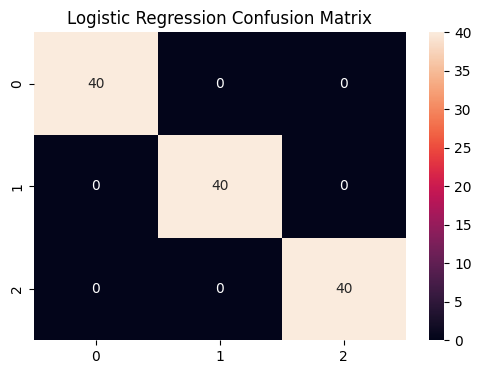

In [30]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, pred_lr),
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig("lr_confusion_matrix.png")

plt.show()

In [31]:
import json

config = {
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000,
    "model_1": {
        "name": "LogisticRegression",
        "max_iter": 1000,
        "C": 1
    },
    "model_2": {
        "name": "MultinomialNB"
    }
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)

print("config.json created successfully")

config.json created successfully


## Configuration Management

A config.json file was created to store all important parameters including random seed, test size, maximum features, and model hyperparameters. This improves reproducibility and reduces hardcoded values in the notebook.

In [32]:
import sklearn
import pandas
import numpy
import matplotlib
import seaborn

print("pandas==", pandas.__version__)
print("numpy==", numpy.__version__)
print("scikit-learn==", sklearn.__version__)
print("matplotlib==", matplotlib.__version__)
print("seaborn==", seaborn.__version__)

pandas== 2.3.3
numpy== 2.4.6
scikit-learn== 1.6.1
matplotlib== 3.10.0
seaborn== 0.13.2


# Legal Notice Classification

## Project Description

This project implements a multi-class text classification system for legal notices. The objective is to classify notices into:

- Contract Dispute
- Intellectual Property Claim
- Regulatory Compliance

## Dataset

- Total Samples: 600
- Classes: 3
- Balanced Dataset

## Models Used

1. Logistic Regression with TF-IDF
2. Naive Bayes with Bag of Words

## Results

Both models achieved:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-Score: 100%

## Configuration

All parameters are stored in config.json.

## How to Run

1. Load dataset
2. Preprocess text
3. Extract features
4. Train models
5. Evaluate results

GitHub Commit Messages

Initial project setup and dataset loading

Completed EDA and preprocessing pipeline

Implemented feature extraction and model training

Added evaluation metrics and confusion matrices

Added config file and documentation

# Part 4.2 Project Structure

## Creating preprocess.py Module

In [35]:
import os

os.makedirs("src", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("notebooks", exist_ok=True)
os.makedirs("mlruns", exist_ok=True)

print("All folders created successfully")

All folders created successfully


In [36]:
with open("src/preprocess.py","w") as f:
    f.write("""
def preprocess(text):
    return text.lower()
""")

print("preprocess.py created")

preprocess.py created


In [37]:
with open("src/features.py","w") as f:
    f.write("""
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
""")

print("features.py created")

features.py created


In [38]:
with open("src/evaluate.py","w") as f:
    f.write("""
from sklearn.metrics import accuracy_score
""")

print("evaluate.py created")

evaluate.py created
